### Anime Recommendation

---

![Anime Welcome](https://cdn.myanimelist.net/images/anime/1208/94745.jpg)

### 🎌 Konnichiwa! (こんにちは)
**Welcome to the Anime Recommendation Project! Let's load our dataset and meet our data guests.**

In [19]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [20]:
anm  = pd.read_csv('anime.csv')
rat = pd.read_csv('rating.csv')

In [21]:
anm.head(10)

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266
5,32935,Haikyuu!!: Karasuno Koukou VS Shiratorizawa Ga...,"Comedy, Drama, School, Shounen, Sports",TV,10,9.15,93351
6,11061,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",TV,148,9.13,425855
7,820,Ginga Eiyuu Densetsu,"Drama, Military, Sci-Fi, Space",OVA,110,9.11,80679
8,15335,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...,"Action, Comedy, Historical, Parody, Samurai, S...",Movie,1,9.10,72534
9,15417,Gintama&#039;: Enchousen,"Action, Comedy, Historical, Parody, Samurai, S...",TV,13,9.11,81109


In [22]:
rat.head(10)

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1
5,1,355,-1
6,1,356,-1
7,1,442,-1
8,1,487,-1
9,1,846,-1


In [23]:
anm.columns.tolist()

['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members']

In [24]:
rat.columns.tolist()

['user_id', 'anime_id', 'rating']

In [25]:
anm.info()

<class 'pandas.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  str    
 2   genre     12232 non-null  str    
 3   type      12269 non-null  str    
 4   episodes  12294 non-null  str    
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 1.3 MB


In [26]:
rat.info()

<class 'pandas.DataFrame'>
RangeIndex: 7813737 entries, 0 to 7813736
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
 2   rating    int64
dtypes: int64(3)
memory usage: 178.8 MB


In [27]:
anm.shape

(12294, 7)

In [28]:
rat.shape

(7813737, 3)

In [29]:
anm.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [30]:
rat.describe()

,user_id,anime_id,rating
count,7.813737e+06,7.813737e+06,7.813737e+06
mean,3.672796e+04,8.909072e+03,6.144030e+00
std,2.099795e+04,8.883950e+03,3.727800e+00
min,1.000000e+00,1.000000e+00,-1.000000e+00
25%,1.897400e+04,1.240000e+03,6.000000e+00
50%,3.679100e+04,6.213000e+03,7.000000e+00
75%,5.475700e+04,1.409300e+04,9.000000e+00
max,7.351600e+04,3.451900e+04,1.000000e+01


In [31]:
anm.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [32]:
rat.isnull().sum()

user_id     0
anime_id    0
rating      0
dtype: int64

![EDA](https://cdn.myanimelist.net/images/anime/1286/99889.jpg)

### 🔍 Exploratory Data Analysis

**Time to explore the data - just like how our favourite anime characters train to unlock their true power!**

In [33]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print("Libraries loaded.")

Libraries loaded.


In [34]:
anm = anm.rename(columns={'rating': 'avg_rating'})
rat = rat.rename(columns={'rating': 'user_rating'})

print("anm columns:", anm.columns.tolist())
print("rat columns:", rat.columns.tolist())

anm columns: ['anime_id', 'name', 'genre', 'type', 'episodes', 'avg_rating', 'members']
rat columns: ['user_id', 'anime_id', 'user_rating']


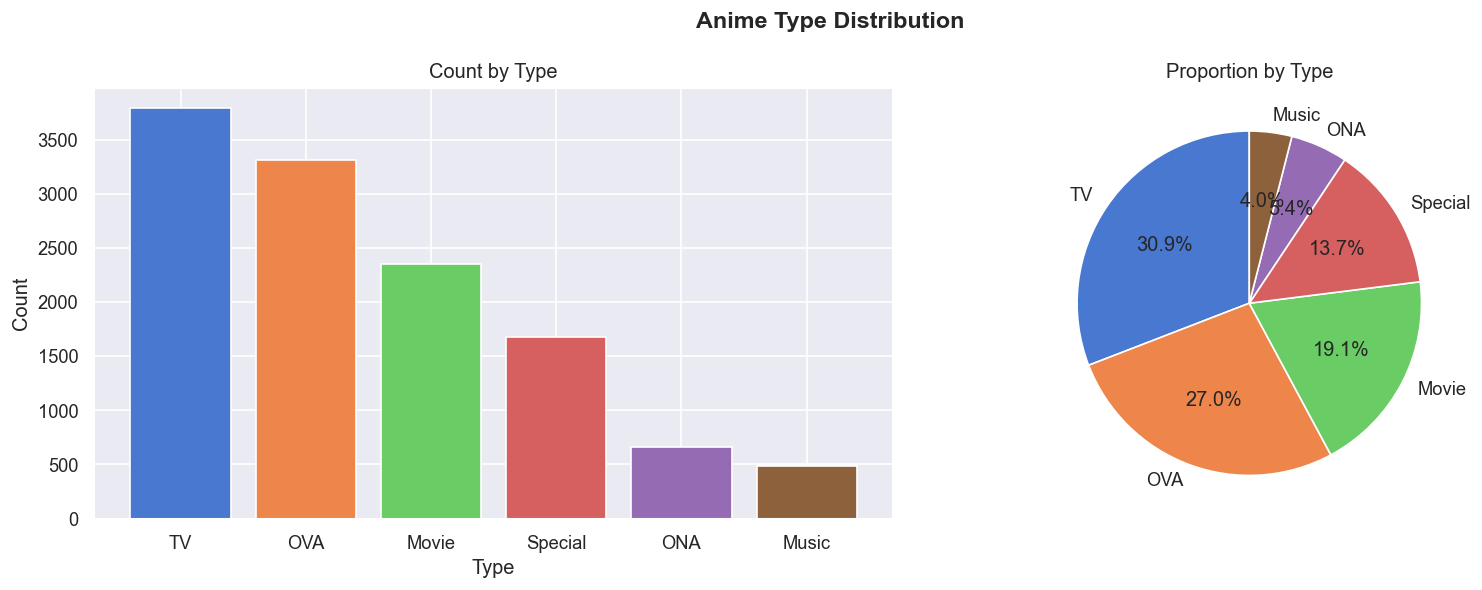

type
TV         3787
OVA        3311
Movie      2348
Special    1676
ONA         659
Music       488
Name: count, dtype: int64


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Anime Type Distribution', fontsize=14, fontweight='bold')

type_counts = anm['type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values,
            color=sns.color_palette('muted'), edgecolor='white')
axes[0].set_title('Count by Type')
axes[0].set_xlabel('Type'); axes[0].set_ylabel('Count')

axes[1].pie(type_counts, labels=type_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('muted'),
            wedgeprops={'edgecolor':'white'})
axes[1].set_title('Proportion by Type')

plt.tight_layout()
plt.show()
print(type_counts)

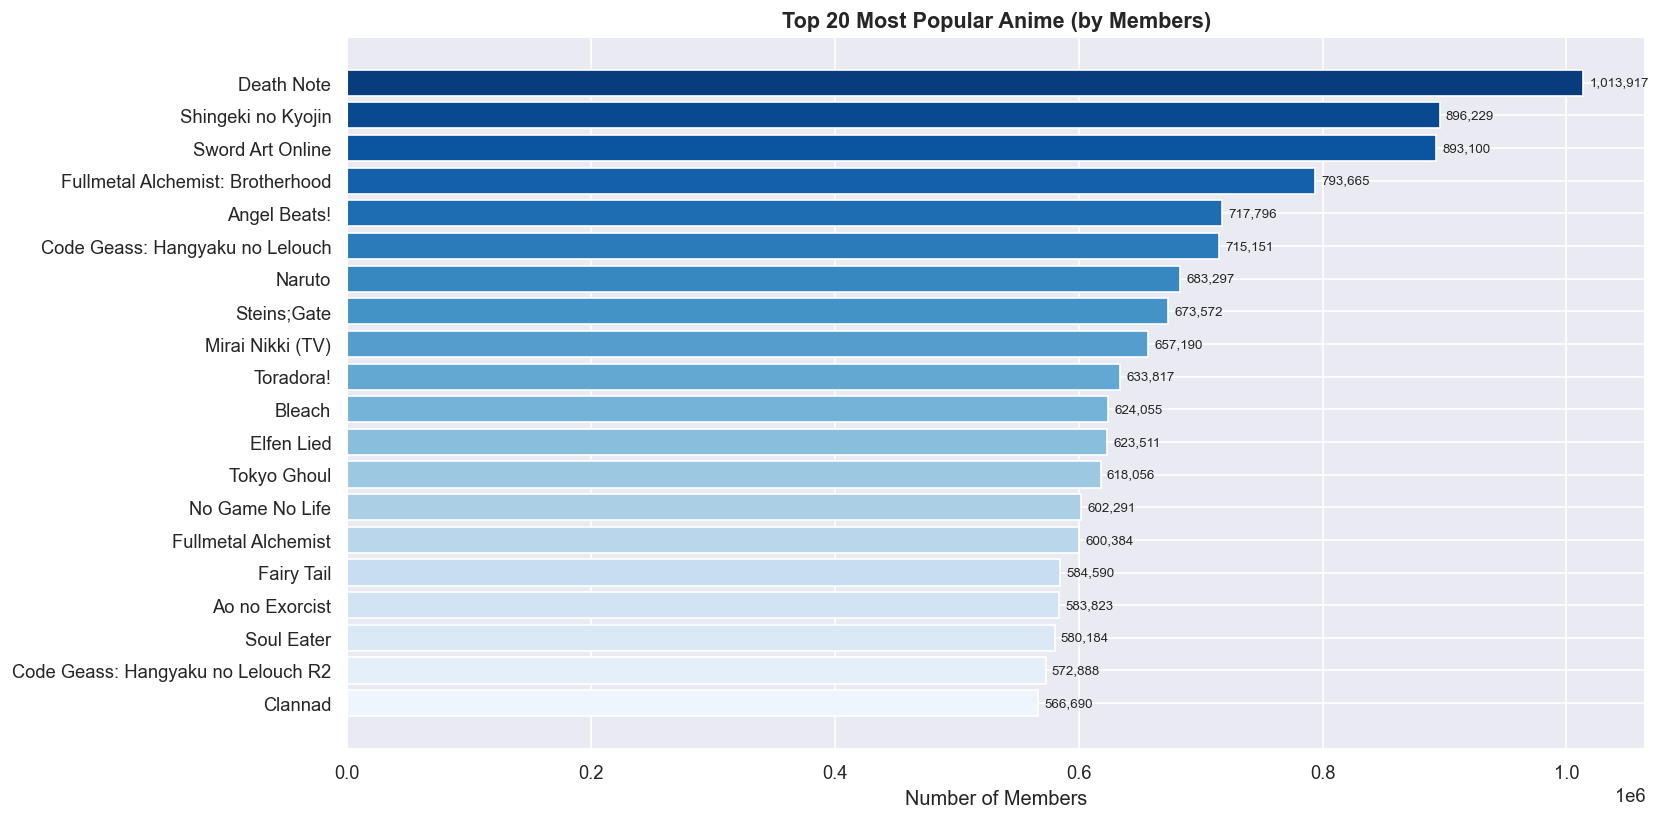

In [36]:
top20 = anm.nlargest(20, 'members')

plt.figure(figsize=(14, 7))
bars = plt.barh(top20['name'], top20['members'],
                color=sns.color_palette('Blues_r', 20), edgecolor='white')
plt.title('Top 20 Most Popular Anime (by Members)', fontsize=13, fontweight='bold')
plt.xlabel('Number of Members')
plt.gca().invert_yaxis()
for bar, val in zip(bars, top20['members']):
    plt.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

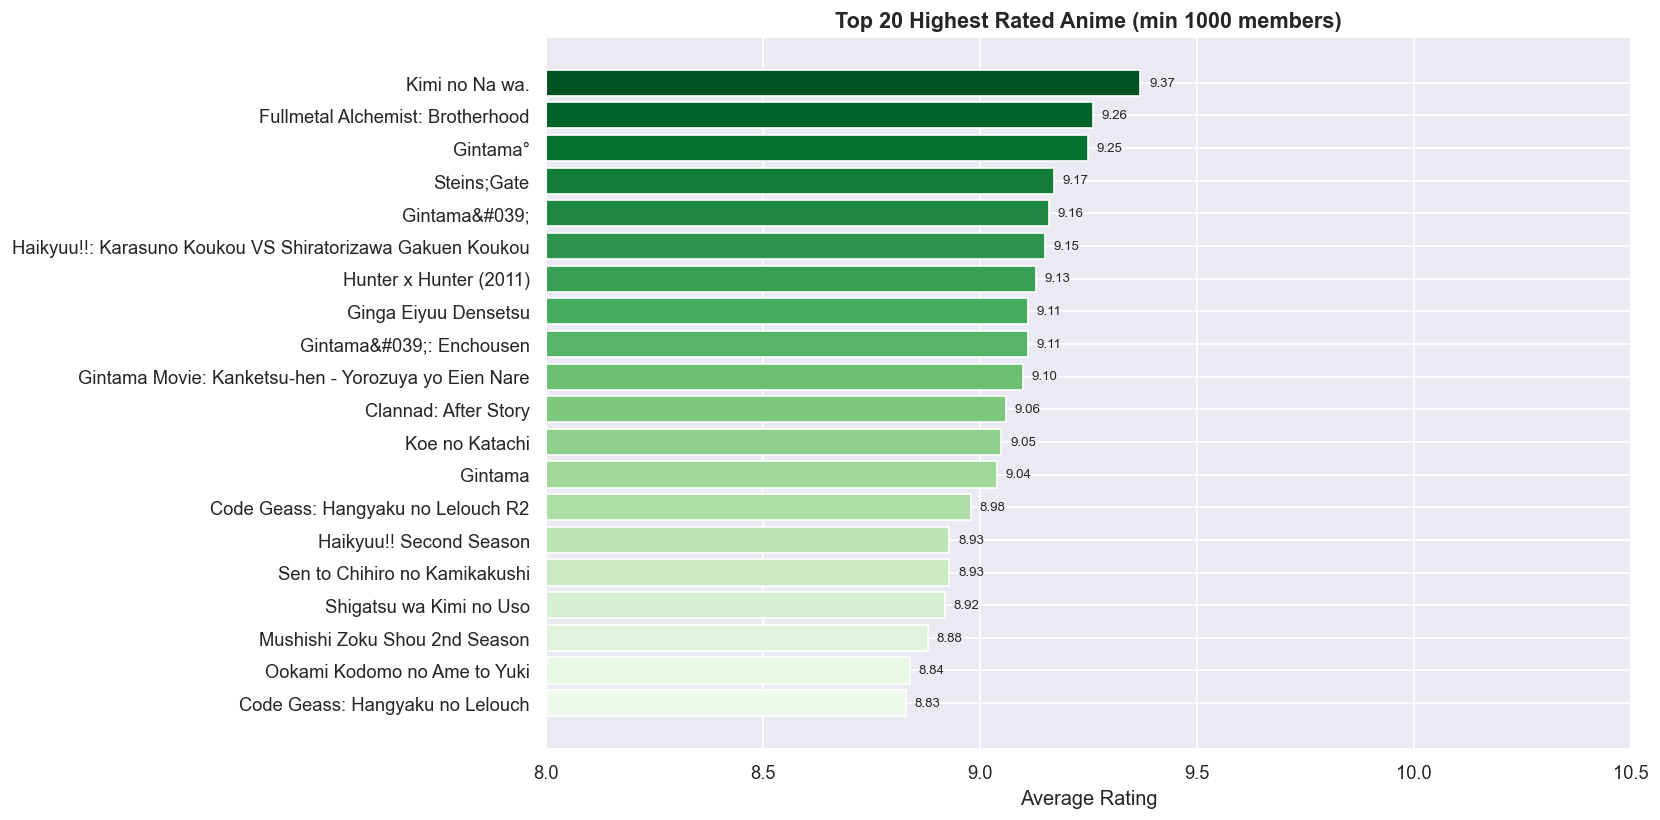

In [37]:
top_rated = anm[anm['members'] >= 1000].nlargest(20, 'avg_rating')

plt.figure(figsize=(14, 7))
bars = plt.barh(top_rated['name'], top_rated['avg_rating'],
                color=sns.color_palette('Greens_r', 20), edgecolor='white')
plt.title('Top 20 Highest Rated Anime (min 1000 members)', fontsize=13, fontweight='bold')
plt.xlabel('Average Rating')
plt.xlim(8, 10.5)
plt.gca().invert_yaxis()
for bar, val in zip(bars, top_rated['avg_rating']):
    plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

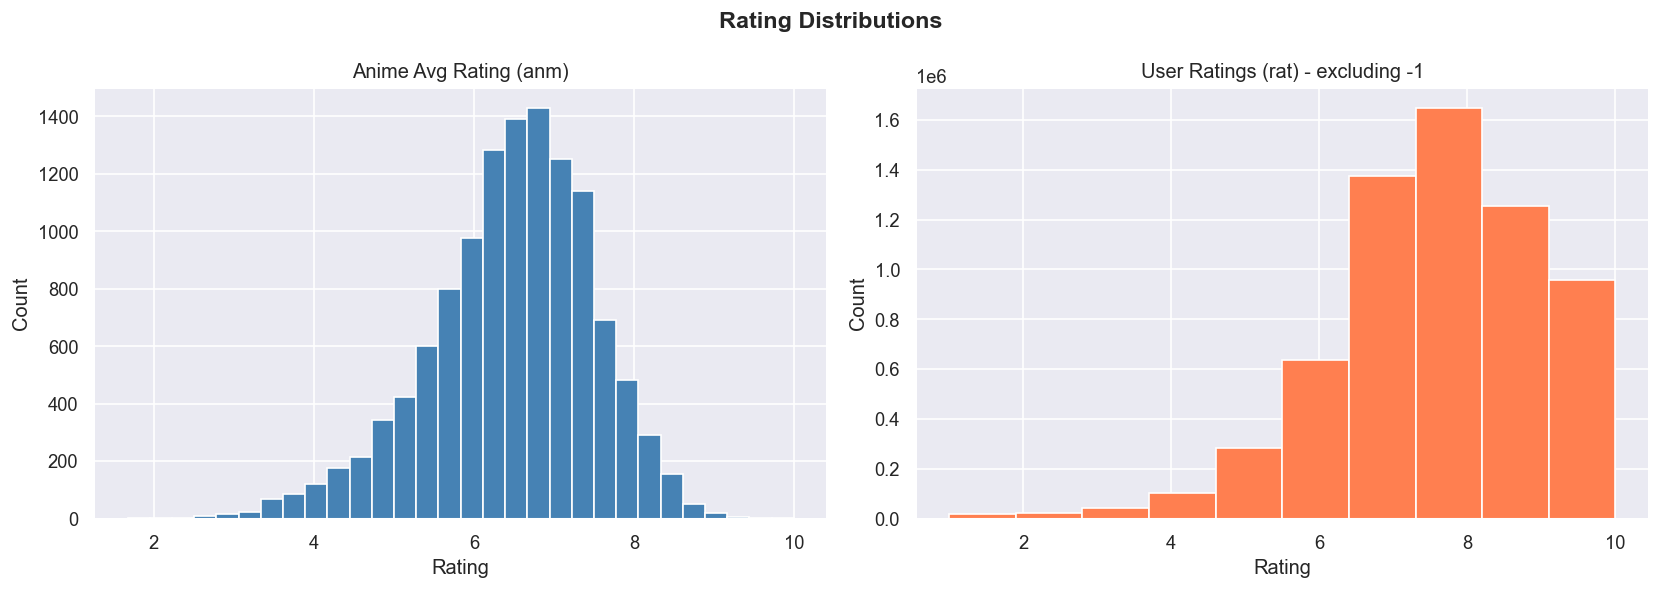

Unrated (-1) in rat : 1,476,496
Rated entries       : 6,337,241


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Rating Distributions', fontsize=14, fontweight='bold')

anm['avg_rating'].dropna().plot(kind='hist', bins=30, ax=axes[0],
                                 color='steelblue', edgecolor='white')
axes[0].set_title('Anime Avg Rating (anm)')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Count')

user_rated = rat[rat['user_rating'] != -1]
user_rated['user_rating'].plot(kind='hist', bins=10, ax=axes[1],
                                color='coral', edgecolor='white')
axes[1].set_title('User Ratings (rat) - excluding -1')
axes[1].set_xlabel('Rating'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Unrated (-1) in rat : {(rat['user_rating']==-1).sum():,}")
print(f"Rated entries       : {(rat['user_rating']!=-1).sum():,}")

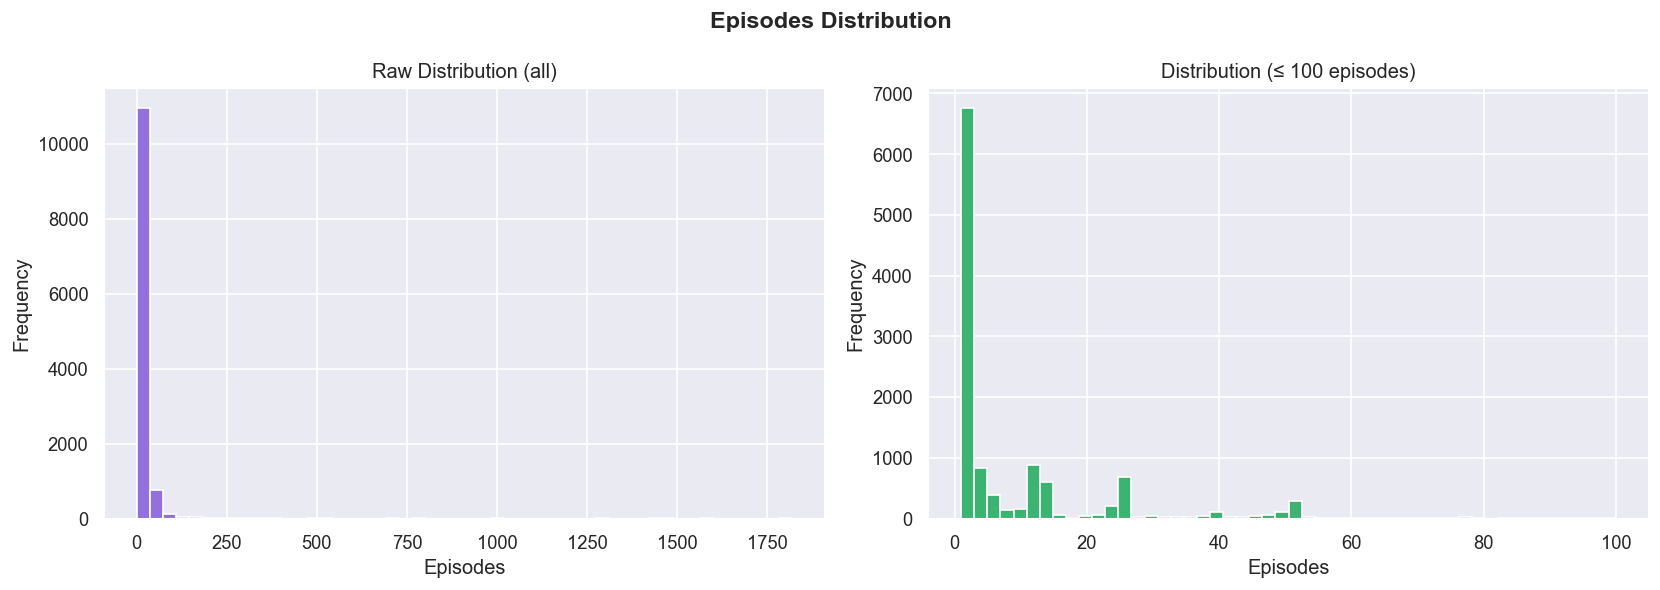

count    11954.000000
mean        12.382550
std         46.865352
min          1.000000
25%          1.000000
50%          2.000000
75%         12.000000
max       1818.000000
Name: episodes, dtype: float64


In [39]:
anm['episodes'] = pd.to_numeric(anm['episodes'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Episodes Distribution', fontsize=14, fontweight='bold')

anm['episodes'].dropna().plot(kind='hist', bins=50, ax=axes[0],
                               color='mediumpurple', edgecolor='white')
axes[0].set_title('Raw Distribution (all)')
axes[0].set_xlabel('Episodes')

anm[anm['episodes'] <= 100]['episodes'].plot(
    kind='hist', bins=50, ax=axes[1],
    color='mediumseagreen', edgecolor='white')
axes[1].set_title('Distribution (≤ 100 episodes)')
axes[1].set_xlabel('Episodes')

plt.tight_layout()
plt.show()
print(anm['episodes'].describe())

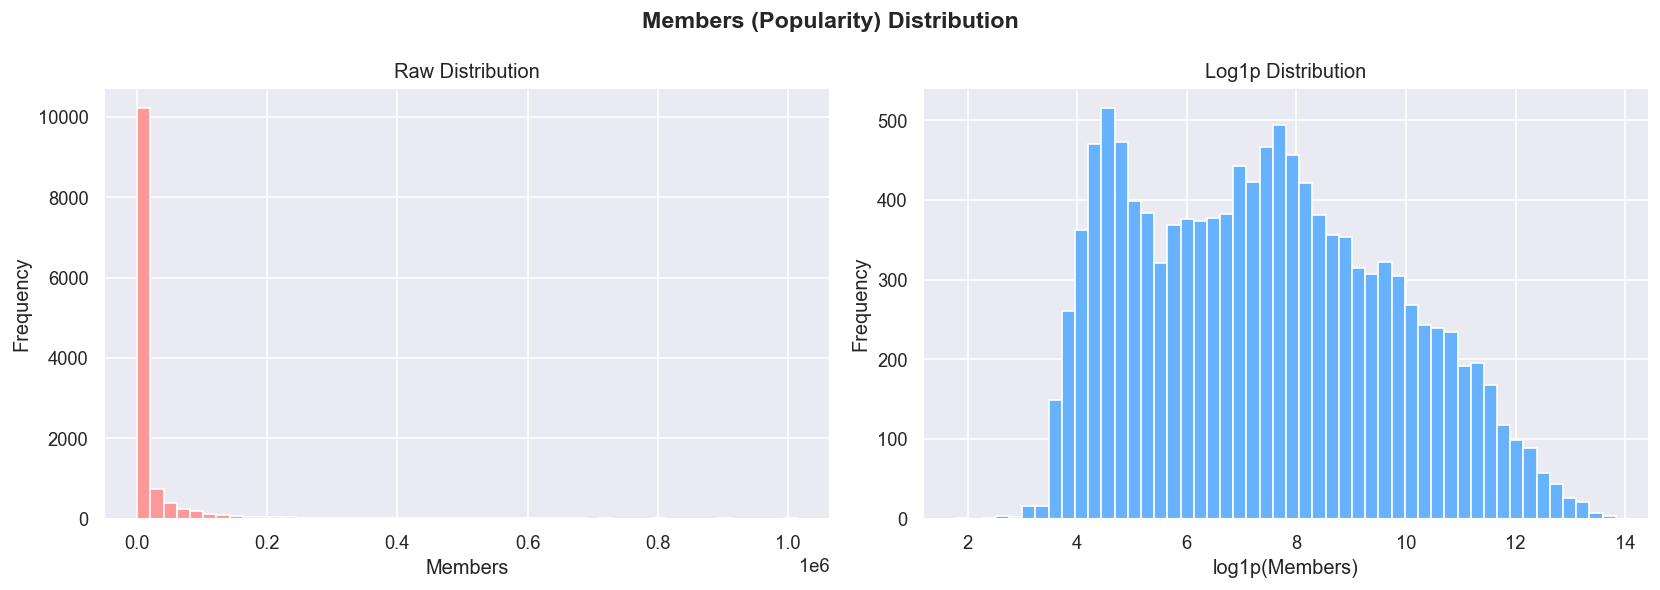

count    1.229400e+04
mean     1.807134e+04
std      5.482068e+04
min      5.000000e+00
25%      2.250000e+02
50%      1.550000e+03
75%      9.437000e+03
max      1.013917e+06
Name: members, dtype: float64


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Members (Popularity) Distribution', fontsize=14, fontweight='bold')

anm['members'].plot(kind='hist', bins=50, ax=axes[0],
                     color='#FF9999', edgecolor='white')
axes[0].set_title('Raw Distribution')
axes[0].set_xlabel('Members')

np.log1p(anm['members']).plot(kind='hist', bins=50, ax=axes[1],
                               color='#66B2FF', edgecolor='white')
axes[1].set_title('Log1p Distribution')
axes[1].set_xlabel('log1p(Members)')

plt.tight_layout()
plt.show()
print(anm['members'].describe())

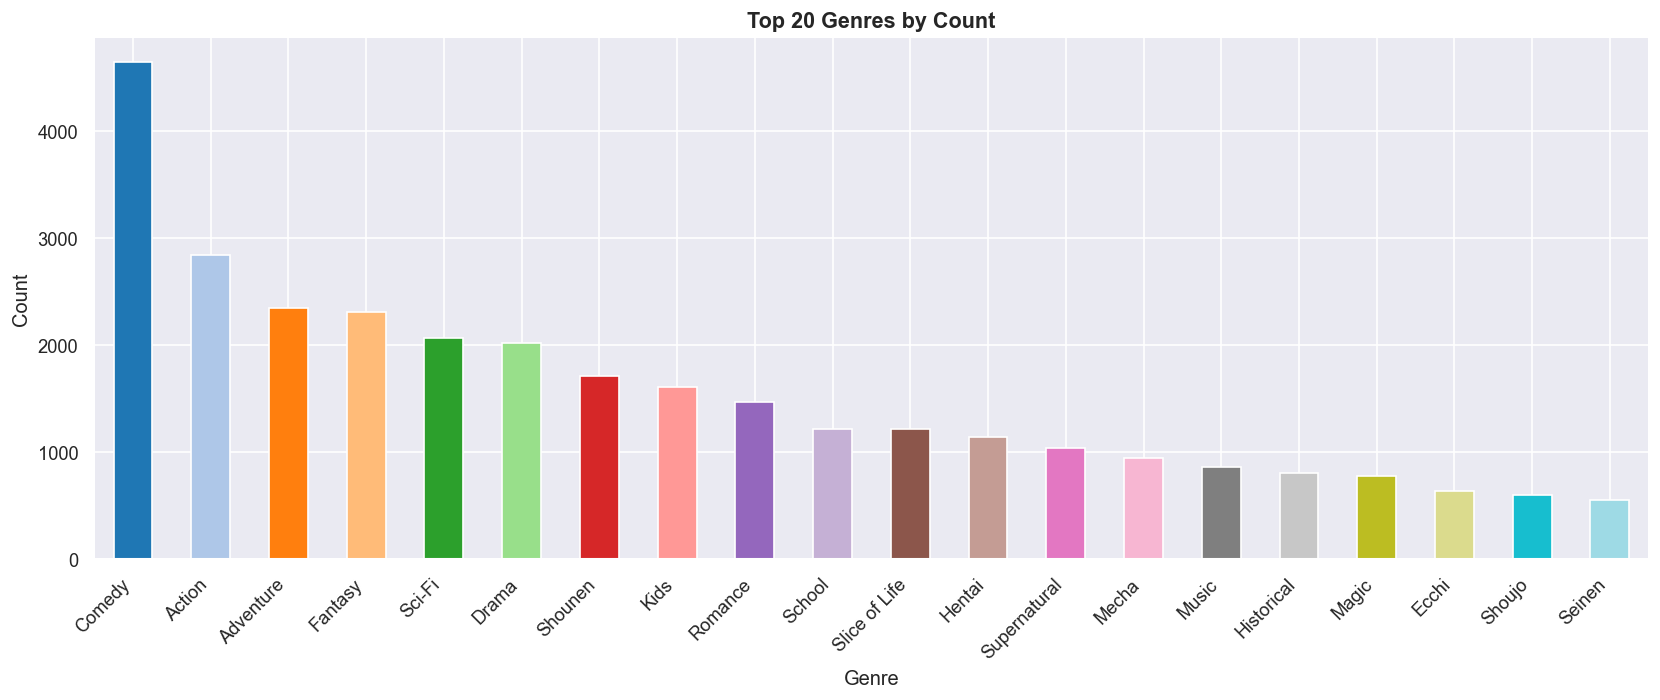

Total unique genres: 43


In [41]:
genre_series = anm['genre'].dropna().str.split(',').explode().str.strip()
top_genres   = genre_series.value_counts().head(20)

plt.figure(figsize=(14, 6))
top_genres.plot(kind='bar', color=sns.color_palette('tab20', 20), edgecolor='white')
plt.title('Top 20 Genres by Count', fontsize=13, fontweight='bold')
plt.xlabel('Genre'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(f"Total unique genres: {genre_series.nunique()}")

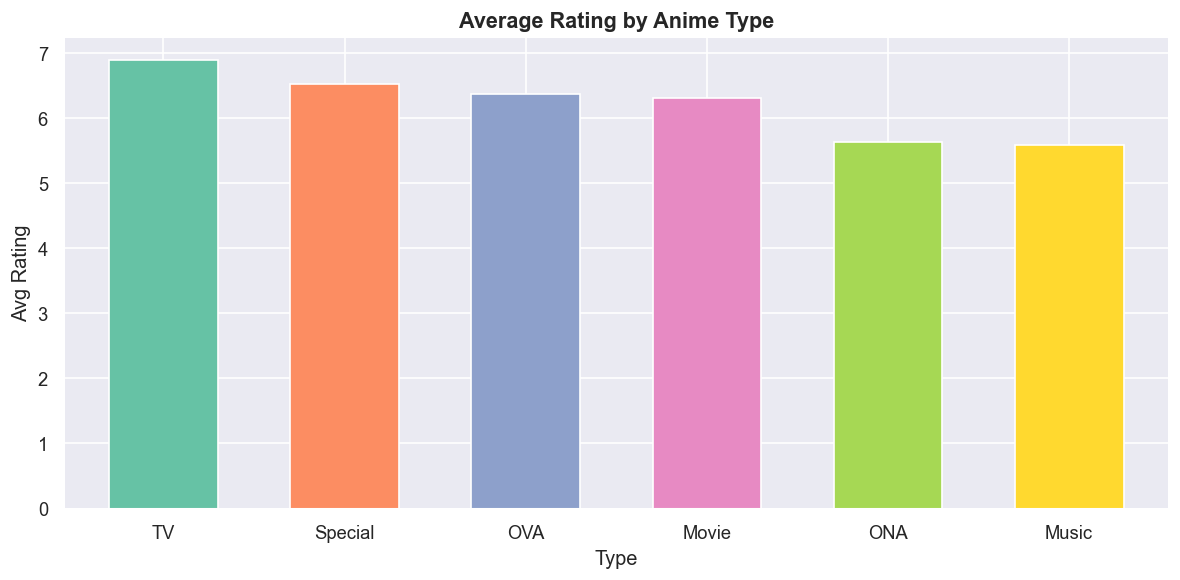

In [42]:
plt.figure(figsize=(10, 5))
anm.groupby('type')['avg_rating'].mean().sort_values(ascending=False).plot(
    kind='bar', color=sns.color_palette('Set2'), edgecolor='white', width=0.6)
plt.title('Average Rating by Anime Type', fontsize=13, fontweight='bold')
plt.xlabel('Type'); plt.ylabel('Avg Rating')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

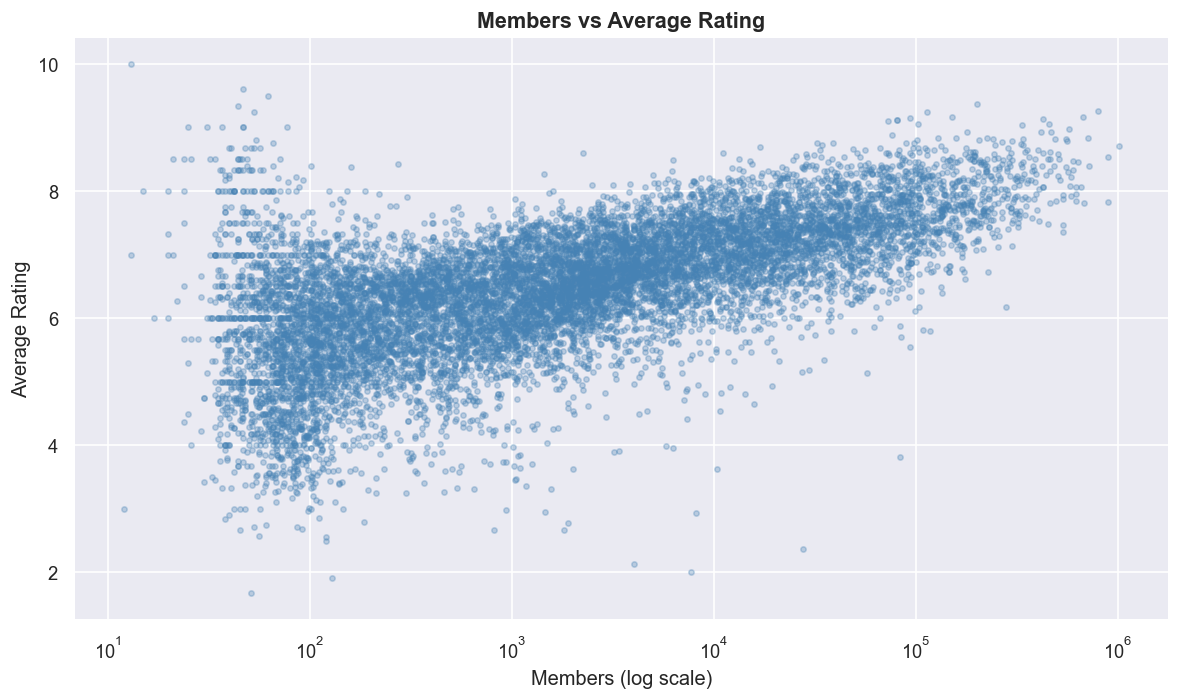

Correlation (members vs avg_rating): 0.3880


In [43]:
plt.figure(figsize=(10, 6))
scatter_data = anm.dropna(subset=['avg_rating'])
plt.scatter(scatter_data['members'], scatter_data['avg_rating'],
            alpha=0.3, s=10, c='steelblue')
plt.xscale('log')
plt.title('Members vs Average Rating', fontsize=13, fontweight='bold')
plt.xlabel('Members (log scale)')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

print(f"Correlation (members vs avg_rating): "
      f"{scatter_data[['members','avg_rating']].corr().iloc[0,1]:.4f}")

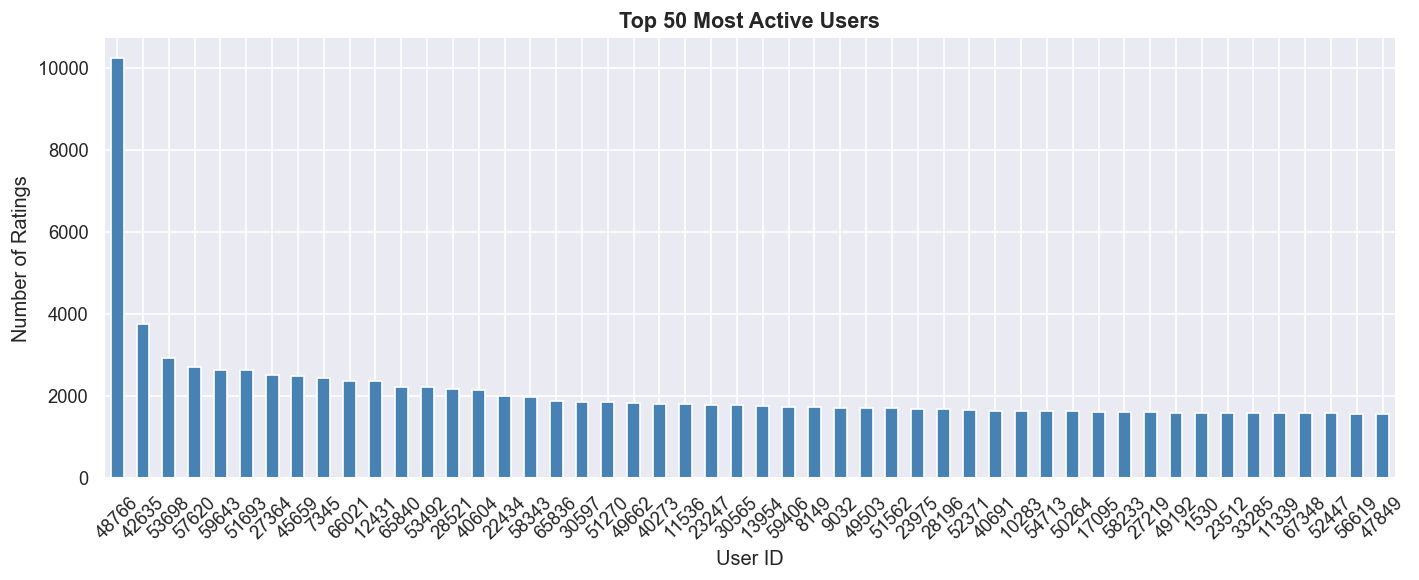

Avg ratings per user : 106.3
Max ratings by a user: 10,227
Total unique users   : 73,515


In [44]:
ratings_per_user = rat.groupby('user_id')['user_rating'].count().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
ratings_per_user.head(50).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 50 Most Active Users', fontsize=13, fontweight='bold')
plt.xlabel('User ID'); plt.ylabel('Number of Ratings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Avg ratings per user : {ratings_per_user.mean():.1f}")
print(f"Max ratings by a user: {ratings_per_user.max():,}")
print(f"Total unique users   : {rat['user_id'].nunique():,}")

![Transform](https://cdn.myanimelist.net/images/anime/1337/99013.jpg)

### 📊 Distribution Check & Transformations
**Checking skewness and transforming our data - because even raw data needs training before it becomes powerful!**

In [45]:
#Skewness-Numeric Colomns

numeric_cols = ['episodes', 'avg_rating', 'members']

skew_df = anm[numeric_cols].skew().sort_values(ascending=False).reset_index()
skew_df.columns = ['Feature', 'Skewness']
skew_df['Severity'] = pd.cut(skew_df['Skewness'].abs(),
                              bins=[-1, 0.5, 1.0, np.inf],
                              labels=['Approx Normal', 'Moderate Skew', 'High Skew'])

print(f"High Skew   (|skew| > 1.0) : {(skew_df['Severity']=='High Skew').sum()}")
print(f"Moderate    (0.5 – 1.0)    : {(skew_df['Severity']=='Moderate Skew').sum()}")
print(f"Approx Normal (< 0.5)      : {(skew_df['Severity']=='Approx Normal').sum()}")
print()
print(skew_df.to_string(index=False))

High Skew   (|skew| > 1.0) : 2
Moderate    (0.5 – 1.0)    : 1
Approx Normal (< 0.5)      : 0

   Feature  Skewness      Severity
  episodes 23.385641     High Skew
   members  6.682934     High Skew
avg_rating -0.543570 Moderate Skew


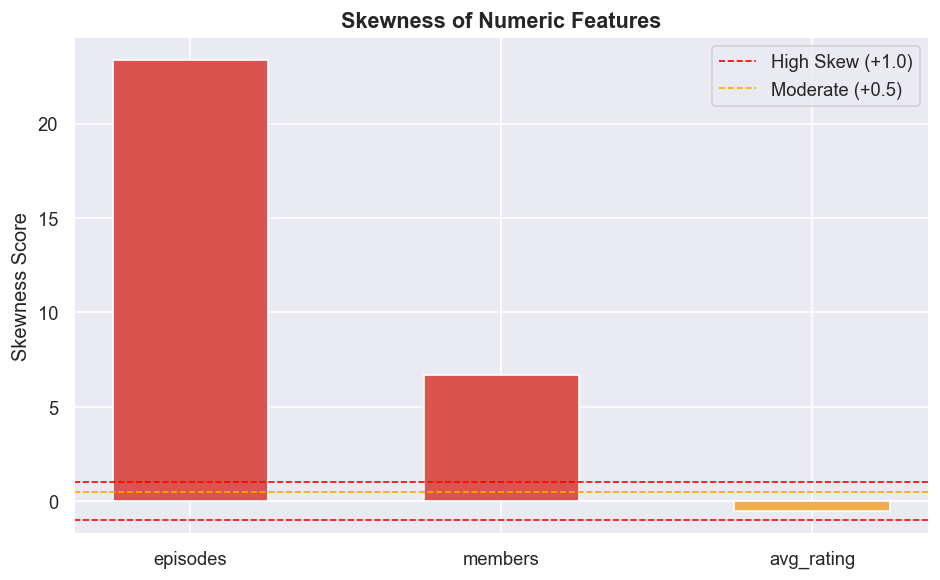

In [46]:
color_map  = {'High Skew':'#d9534f', 'Moderate Skew':'#f0ad4e', 'Approx Normal':'#5cb85c'}
colors_bar = [color_map[str(s)] for s in skew_df['Severity']]

plt.figure(figsize=(8, 5))
plt.bar(skew_df['Feature'], skew_df['Skewness'], color=colors_bar, edgecolor='white', width=0.5)
plt.axhline(y=1.0,  color='red',    linestyle='--', linewidth=1, label='High Skew (+1.0)')
plt.axhline(y=-1.0, color='red',    linestyle='--', linewidth=1)
plt.axhline(y=0.5,  color='orange', linestyle='--', linewidth=1, label='Moderate (+0.5)')
plt.title('Skewness of Numeric Features', fontsize=13, fontweight='bold')
plt.ylabel('Skewness Score')
plt.legend()
plt.tight_layout()
plt.show()

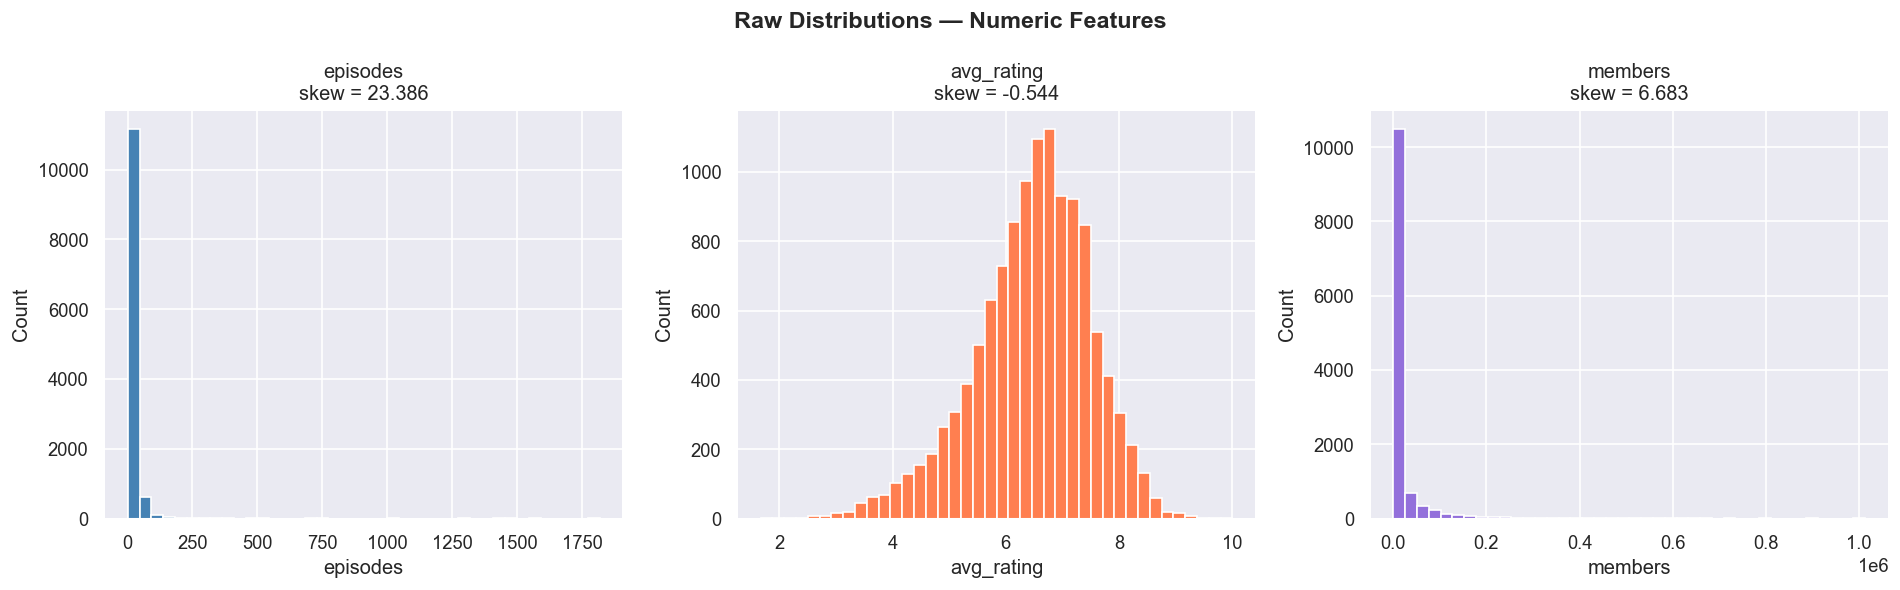

In [47]:
#Raw Distribution-Numerical Features

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Raw Distributions — Numeric Features', fontsize=14, fontweight='bold')

for ax, col, color in zip(axes, numeric_cols, ['steelblue','coral','mediumpurple']):
    anm[col].dropna().plot(kind='hist', bins=40, ax=ax,
                            color=color, edgecolor='white')
    ax.set_title(f'{col}\nskew = {anm[col].skew():.3f}')
    ax.set_xlabel(col); ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

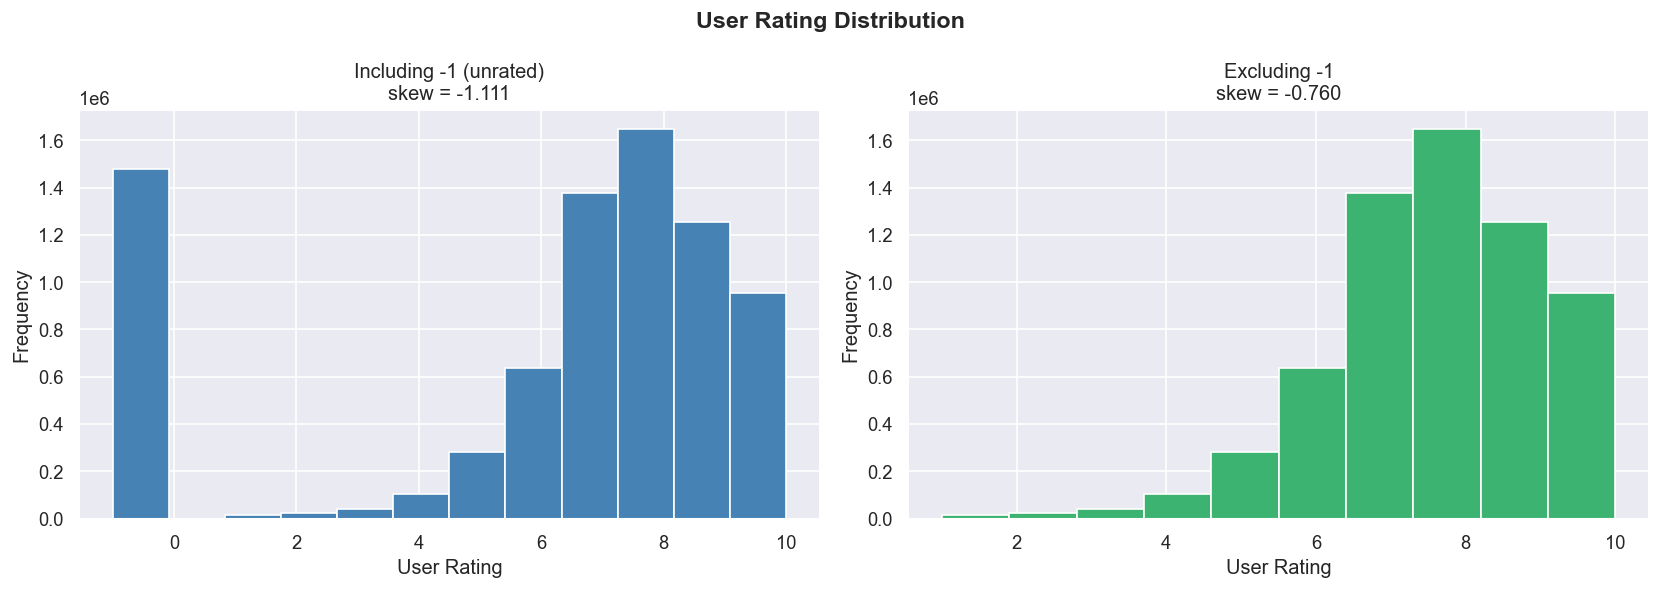

Skewness including -1 : -1.1108
Skewness excluding -1 : -0.7602


In [48]:
#User Distribution Rating

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('User Rating Distribution', fontsize=14, fontweight='bold')

# Including -1
rat['user_rating'].plot(kind='hist', bins=12, ax=axes[0],
                         color='steelblue', edgecolor='white')
axes[0].set_title(f'Including -1 (unrated)\nskew = {rat["user_rating"].skew():.3f}')
axes[0].set_xlabel('User Rating')

# Excluding -1
rat_clean = rat[rat['user_rating'] != -1]
rat_clean['user_rating'].plot(kind='hist', bins=10, ax=axes[1],
                               color='mediumseagreen', edgecolor='white')
axes[1].set_title(f'Excluding -1\nskew = {rat_clean["user_rating"].skew():.3f}')
axes[1].set_xlabel('User Rating')

plt.tight_layout()
plt.show()

print(f"Skewness including -1 : {rat['user_rating'].skew():.4f}")
print(f"Skewness excluding -1 : {rat_clean['user_rating'].skew():.4f}")

In [49]:
from scipy import stats

#Transformation

anm_transformed = anm.copy()

# 1. members; log1p (highly right skewed)
anm_transformed['members_log'] = np.log1p(anm['members'])

# 2. episodes; log1p (right skewed)
anm_transformed['episodes_log'] = np.log1p(anm['episodes'])

# 3. avg_rating; already near-normal, check skewness
print("Skewness BEFORE transformation:")
print(f"  members  : {anm['members'].skew():.4f}")
print(f"  episodes : {anm['episodes'].skew():.4f}")
print(f"  avg_rating: {anm['avg_rating'].skew():.4f}")

print("\nSkewness AFTER transformation:")
print(f"  members_log  : {anm_transformed['members_log'].skew():.4f}")
print(f"  episodes_log : {anm_transformed['episodes_log'].skew():.4f}")
print(f"  avg_rating   : no transform needed")

Skewness BEFORE transformation:
  members  : 6.6829
  episodes : 23.3856
  avg_rating: -0.5436

Skewness AFTER transformation:
  members_log  : 0.2661
  episodes_log : 1.0123
  avg_rating   : no transform needed


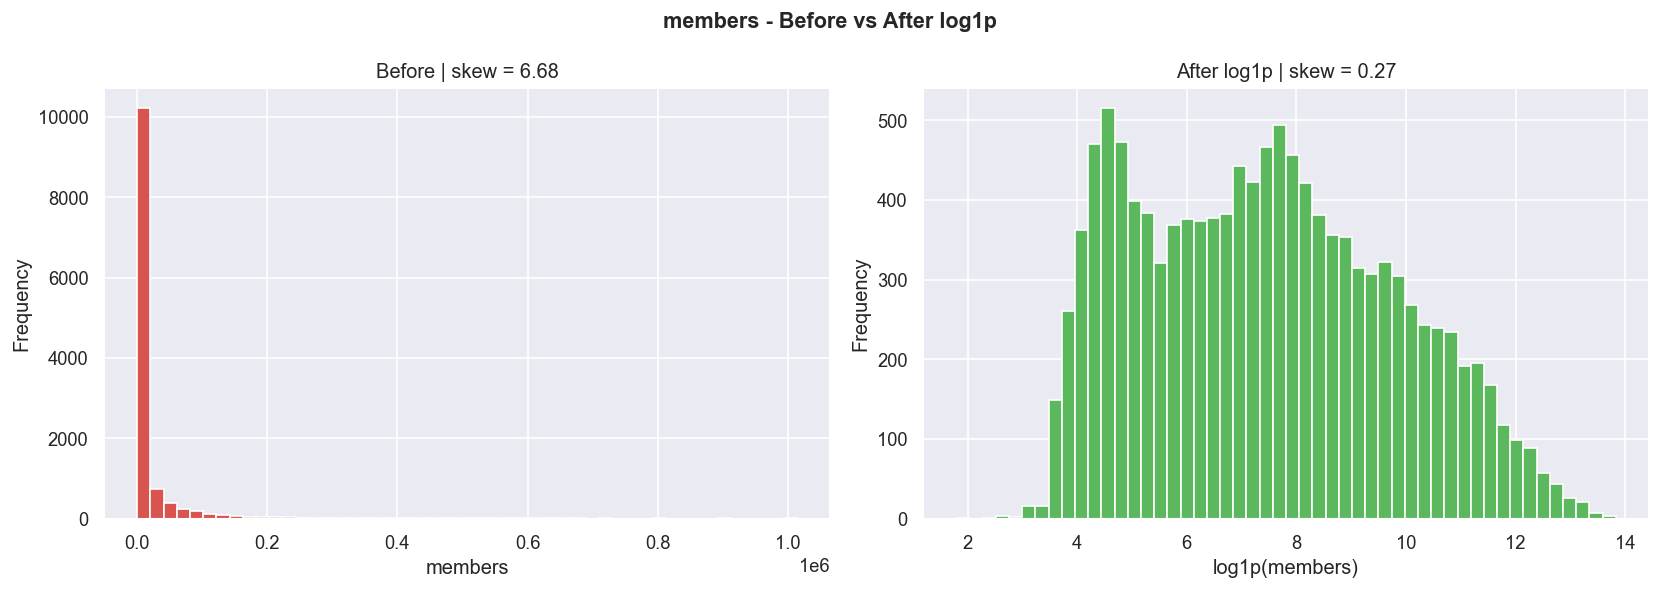

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('members - Before vs After log1p', fontsize=13, fontweight='bold')

anm['members'].plot(kind='hist', bins=50, ax=axes[0],
                     color='#d9534f', edgecolor='white')
axes[0].set_title(f'Before | skew = {anm["members"].skew():.2f}')
axes[0].set_xlabel('members')

anm_transformed['members_log'].plot(kind='hist', bins=50, ax=axes[1],
                                     color='#5cb85c', edgecolor='white')
axes[1].set_title(f'After log1p | skew = {anm_transformed["members_log"].skew():.2f}')
axes[1].set_xlabel('log1p(members)')

plt.tight_layout()
plt.show()

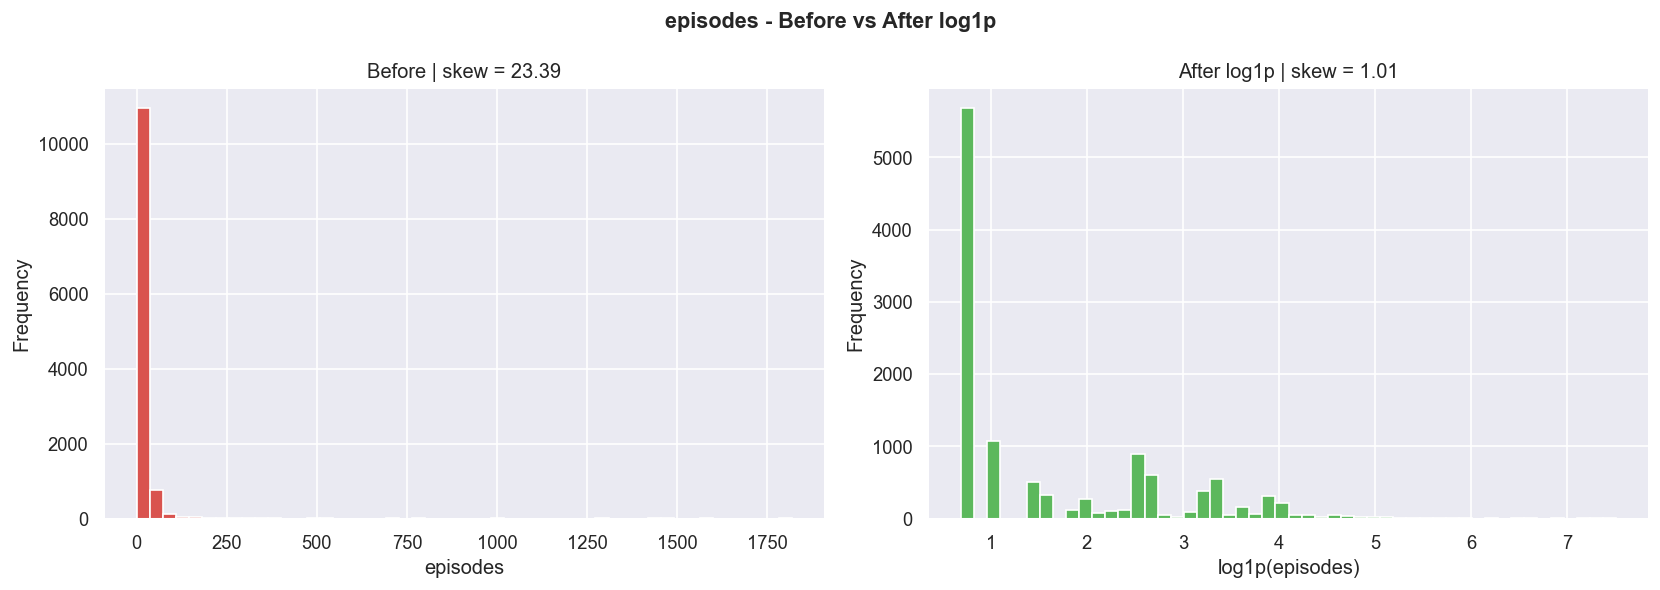

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('episodes - Before vs After log1p', fontsize=13, fontweight='bold')

anm['episodes'].dropna().plot(kind='hist', bins=50, ax=axes[0],
                               color='#d9534f', edgecolor='white')
axes[0].set_title(f'Before | skew = {anm["episodes"].skew():.2f}')
axes[0].set_xlabel('episodes')

anm_transformed['episodes_log'].dropna().plot(kind='hist', bins=50, ax=axes[1],
                                               color='#5cb85c', edgecolor='white')
axes[1].set_title(f'After log1p | skew = {anm_transformed["episodes_log"].skew():.2f}')
axes[1].set_xlabel('log1p(episodes)')

plt.tight_layout()
plt.show()

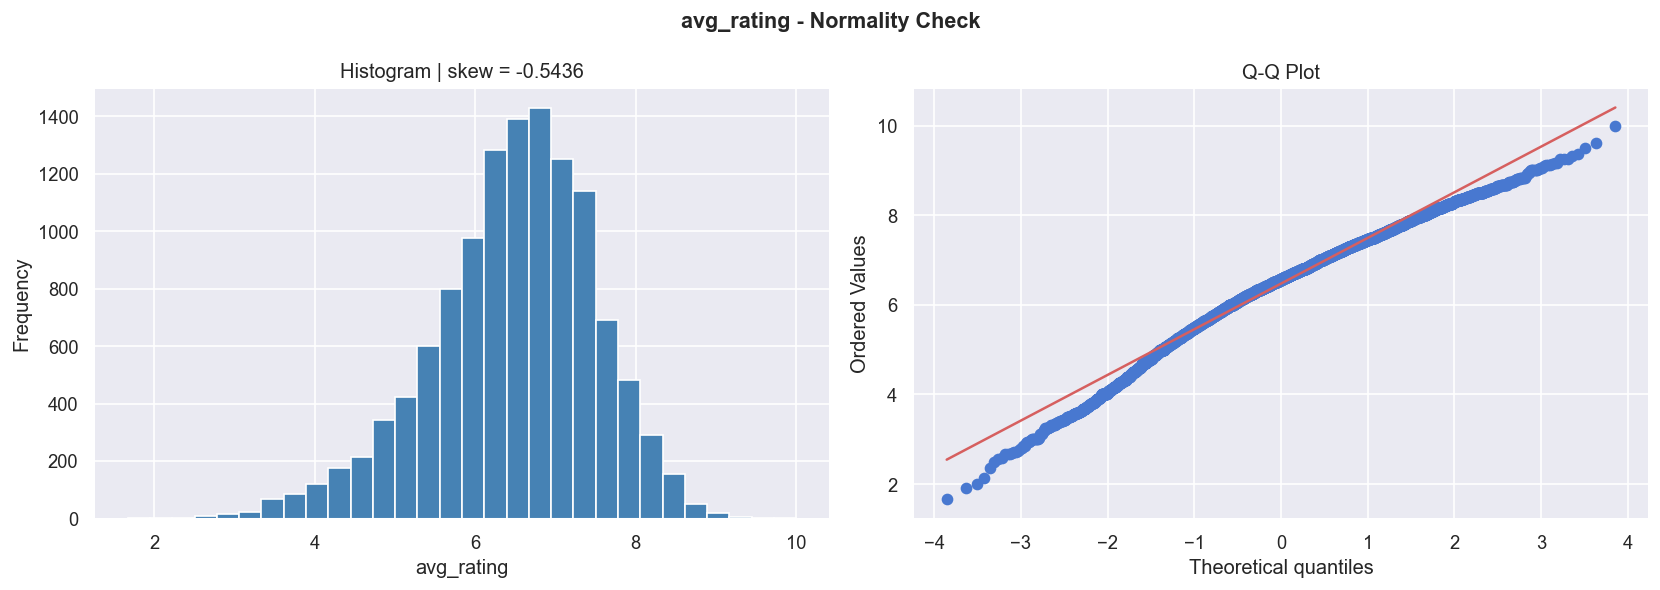

avg_rating skewness : -0.5436
avg_rating kurtosis : 0.5075
avg_rating is approximately normal - no transformation needed.


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('avg_rating - Normality Check', fontsize=13, fontweight='bold')

anm['avg_rating'].dropna().plot(kind='hist', bins=30, ax=axes[0],
                                 color='steelblue', edgecolor='white')
axes[0].set_title(f'Histogram | skew = {anm["avg_rating"].skew():.4f}')
axes[0].set_xlabel('avg_rating')

# Q-Q plot
from scipy.stats import probplot
probplot(anm['avg_rating'].dropna(), dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

print(f"avg_rating skewness : {anm['avg_rating'].skew():.4f}")
print(f"avg_rating kurtosis : {anm['avg_rating'].kurt():.4f}")
print("avg_rating is approximately normal - no transformation needed.")

In [53]:

print("TRANSFORMATION SUMMARY")

print(f"{'Feature':<15} {'Before':>10} {'After':>10}  {'Method'}")
print("-" * 50)
print(f"{'members':<15} {anm['members'].skew():>10.4f} "
      f"{anm_transformed['members_log'].skew():>10.4f}  log1p")
print(f"{'episodes':<15} {anm['episodes'].skew():>10.4f} "
      f"{anm_transformed['episodes_log'].skew():>10.4f}  log1p")
print(f"{'avg_rating':<15} {anm['avg_rating'].skew():>10.4f} "
      f"{'no change':>10}  none needed")
print(f"\nUser rating (-1 removed): skew = {rat_clean['user_rating'].skew():.4f}")
print(f" user_rating is left-skewed (users tend to rate anime they like highly)")

TRANSFORMATION SUMMARY
Feature             Before      After  Method
--------------------------------------------------
members             6.6829     0.2661  log1p
episodes           23.3856     1.0123  log1p
avg_rating         -0.5436  no change  none needed

User rating (-1 removed): skew = -0.7602
 user_rating is left-skewed (users tend to rate anime they like highly)


![Recommender](https://cdn.myanimelist.net/images/anime/1015/138006.jpg)

### 🤖 Content-Based Recommender System
*"Tell me what you watch — I'll tell you what to watch next!"*
Using **TF-IDF** on genre + **Cosine Similarity** to find the most similar anime. 

In [55]:
# Work on a clean copy
anm_cb = anm_transformed.copy()

# Fill missing genres with empty string
anm_cb['genre'] = anm_cb['genre'].fillna('')

# Fill missing type with mode
anm_cb['type'] = anm_cb['type'].fillna(anm_cb['type'].mode()[0])

# Fill missing avg_rating with median
anm_cb['avg_rating'] = anm_cb['avg_rating'].fillna(anm_cb['avg_rating'].median())

# Fill missing episodes_log with median
anm_cb['episodes_log'] = anm_cb['episodes_log'].fillna(anm_cb['episodes_log'].median())

# Reset index
anm_cb = anm_cb.reset_index(drop=True)

print("Missing values after treatment:")
print(anm_cb[['genre','type','avg_rating','episodes_log','members_log']].isnull().sum())
print(f"\nShape: {anm_cb.shape}")

Missing values after treatment:
genre           0
type            0
avg_rating      0
episodes_log    0
members_log     0
dtype: int64

Shape: (12294, 9)


In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Clean genre: replace comma with space so each genre is a token
anm_cb['genre_clean'] = anm_cb['genre'].str.replace(',', ' ').str.strip()

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(anm_cb['genre_clean'])

print(f"TF-IDF matrix shape : {tfidf_matrix.shape}")
print(f"Total genre tokens  : {len(tfidf.get_feature_names_out())}")
print(f"\nSample genre tokens : {tfidf.get_feature_names_out()[:15].tolist()}")

TF-IDF matrix shape : (12294, 46)
Total genre tokens  : 46

Sample genre tokens : ['action', 'adventure', 'ai', 'arts', 'cars', 'comedy', 'dementia', 'demons', 'drama', 'ecchi', 'fantasy', 'fi', 'game', 'harem', 'hentai']


In [57]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from scipy.sparse import hstack, csr_matrix

# One-hot encode type
ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
type_encoded = ohe.fit_transform(anm_cb[['type']])
print(f"Type encoded shape  : {type_encoded.shape}")
print(f"Type categories     : {ohe.categories_[0].tolist()}")

# Normalize numeric features
scaler = MinMaxScaler()
num_features = scaler.fit_transform(
    anm_cb[['avg_rating', 'members_log', 'episodes_log']]
)
num_sparse = csr_matrix(num_features)
print(f"Numeric features shape: {num_sparse.shape}")

Type encoded shape  : (12294, 6)
Type categories     : ['Movie', 'Music', 'ONA', 'OVA', 'Special', 'TV']
Numeric features shape: (12294, 3)


In [58]:
# Weights: genre most important, then type, then numerics
# genre * 3, type * 2, numerics * 1
combined_features = hstack([
    tfidf_matrix * 3,
    type_encoded  * 2,
    num_sparse    * 1
])

print(f"Combined feature matrix shape: {combined_features.shape}")
print("Features: TF-IDF(genre)×3 + OneHot(type)×2 + Normalized(rating,members,episodes)×1")

Combined feature matrix shape: (12294, 55)
Features: TF-IDF(genre)×3 + OneHot(type)×2 + Normalized(rating,members,episodes)×1


In [59]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute cosine similarity
cosine_sim = cosine_similarity(combined_features, combined_features)

print(f"Cosine similarity matrix shape: {cosine_sim.shape}")
print(f"\nSample similarity (first 3 anime vs first 3):")
print(cosine_sim[:3, :3])

# Create index mapping: anime name → index
indices = pd.Series(anm_cb.index, index=anm_cb['name']).drop_duplicates()
print(f"\nTotal anime indexed: {len(indices)}")

Cosine similarity matrix shape: (12294, 12294)

Sample similarity (first 3 anime vs first 3):
[[1.         0.20375027 0.10566695]
 [0.20375027 1.         0.50263035]
 [0.10566695 0.50263035 1.        ]]

Total anime indexed: 12294


In [60]:
def recommend_anime(title, n=10):
    """
    Content-based anime recommender.
    Returns top N similar anime based on genre, type, rating, members, episodes.
    """
    # Check if title exists
    if title not in indices:
        # Try partial match
        matches = [name for name in indices.index if title.lower() in name.lower()]
        if matches:
            print(f"Exact match not found. Did you mean:\n{matches[:5]}")
        else:
            print(f"'{title}' not found in dataset.")
        return None

    idx = indices[title]

    # Get similarity scores for this anime
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort by similarity score descending
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Exclude the anime itself (index 0 after sorting)
    sim_scores = sim_scores[1:n+1]

    # Get anime indices
    anime_indices = [i[0] for i in sim_scores]
    sim_values    = [round(i[1], 4) for i in sim_scores]

    # Build result dataframe
    result = anm_cb.iloc[anime_indices][
        ['name','genre','type','avg_rating','members','episodes']
    ].copy()
    result['similarity_score'] = sim_values
    result = result.reset_index(drop=True)
    result.index += 1

    return result

In [61]:
print("Recommendations for: Naruto")

recs = recommend_anime('Naruto', n=10)
print(recs.to_string())

Recommendations for: Naruto
                      name                                                                   genre type  avg_rating  members  episodes  similarity_score
1       Naruto: Shippuuden                      Action, Comedy, Martial Arts, Shounen, Super Power   TV        7.94   533578       NaN            0.9866
2           Rekka no Honoo                   Action, Adventure, Martial Arts, Shounen, Super Power   TV        7.44    35258      42.0            0.9636
3            Dragon Ball Z  Action, Adventure, Comedy, Fantasy, Martial Arts, Shounen, Super Power   TV        8.32   375662     291.0            0.9618
4          Dragon Ball Kai  Action, Adventure, Comedy, Fantasy, Martial Arts, Shounen, Super Power   TV        7.95   116832      97.0            0.9604
5   Dragon Ball Kai (2014)  Action, Adventure, Comedy, Fantasy, Martial Arts, Shounen, Super Power   TV        8.01    42666      61.0            0.9584
6   Kurokami The Animation                            

In [62]:
print("Recommendations for: Death Note")

recs2 = recommend_anime('Death Note', n=10)
print(recs2.to_string())

Recommendations for: Death Note
                                 name                                                            genre type  avg_rating  members  episodes  similarity_score
1                     Mousou Dairinin    Drama, Mystery, Police, Psychological, Supernatural, Thriller   TV        7.74   137687      13.0            0.9782
2       Higurashi no Naku Koro ni Kai                   Mystery, Psychological, Supernatural, Thriller   TV        8.41   218101      24.0            0.9257
3                    Mirai Nikki (TV)  Action, Mystery, Psychological, Shounen, Supernatural, Thriller   TV        8.07   657190      26.0            0.8873
4           Higurashi no Naku Koro ni           Horror, Mystery, Psychological, Supernatural, Thriller   TV        8.17   359494      26.0            0.8741
5                             Monster  Drama, Horror, Mystery, Police, Psychological, Seinen, Thriller   TV        8.72   247562      74.0            0.8724
6                   Zankyo

In [63]:
print("Recommendations for: One Piece")

recs3 = recommend_anime('One Piece', n=10)
print(recs3.to_string())

Recommendations for: One Piece
                           name                                                  genre type  avg_rating  members  episodes  similarity_score
1   Shingeki no Kyojin Season 2           Action, Drama, Fantasy, Shounen, Super Power   TV        6.57   170054       NaN            0.9516
2            Shingeki no Kyojin           Action, Drama, Fantasy, Shounen, Super Power   TV        8.54   896229      25.0            0.9514
3               Hunter x Hunter                Action, Adventure, Shounen, Super Power   TV        8.48   166255      62.0            0.9121
4        Hunter x Hunter (2011)                Action, Adventure, Shounen, Super Power   TV        9.13   425855     148.0            0.9092
5                 Nano Invaders                Action, Adventure, Shounen, Super Power   TV        7.08      519      52.0            0.8982
6        Katekyo Hitman Reborn!                   Action, Comedy, Shounen, Super Power   TV        8.37   258103     203.0 

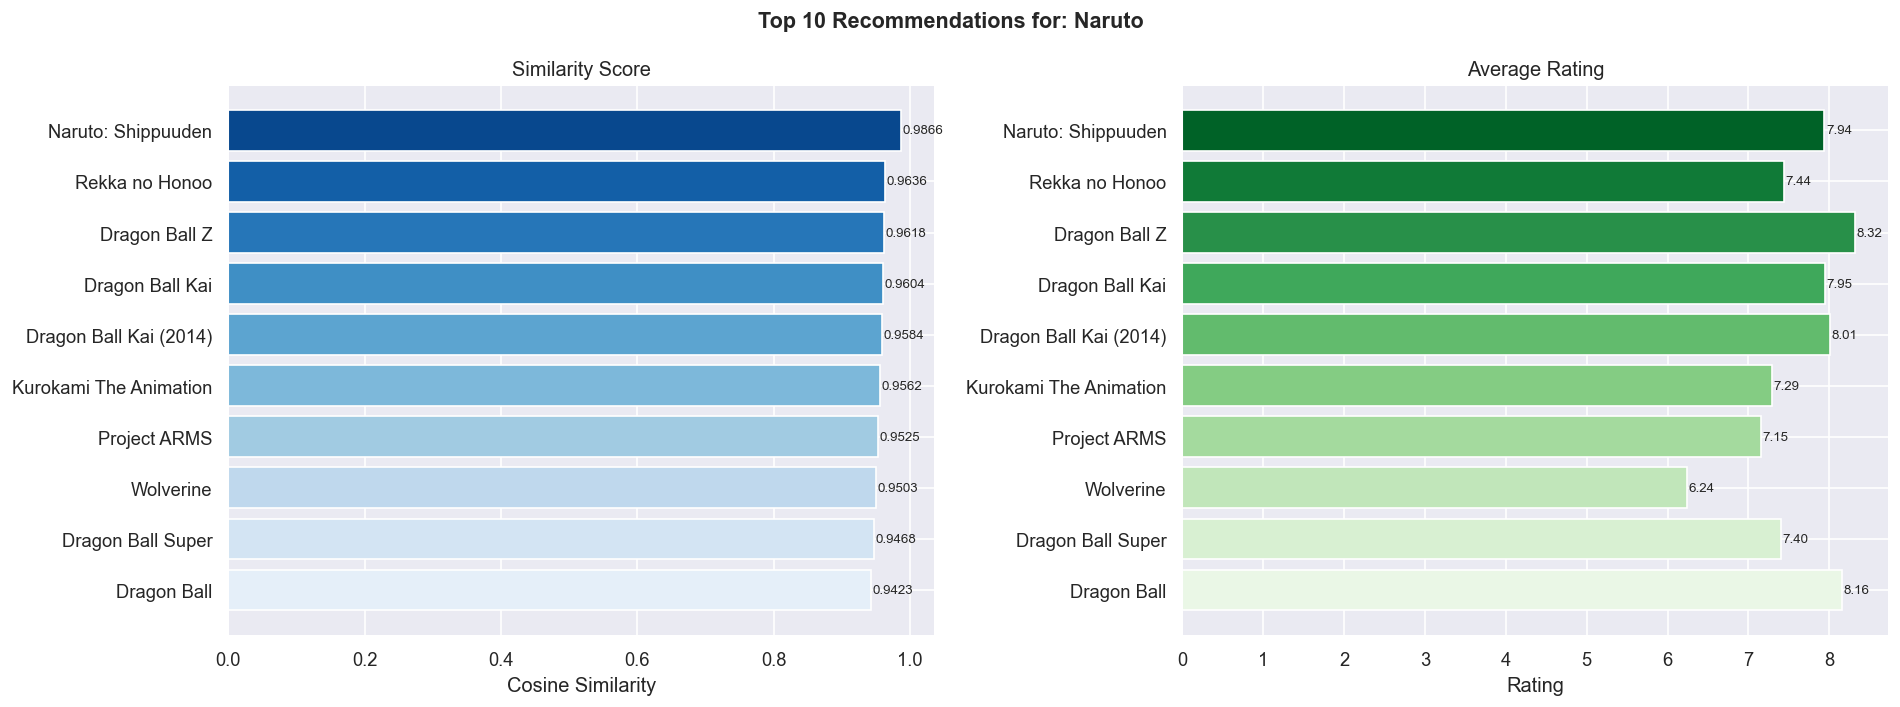

In [64]:
def plot_recommendations(title, n=10):
    recs = recommend_anime(title, n=n)
    if recs is None:
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Top {n} Recommendations for: {title}',
                 fontsize=13, fontweight='bold')

    # Similarity scores bar chart
    axes[0].barh(recs['name'], recs['similarity_score'],
                 color=sns.color_palette('Blues_r', n), edgecolor='white')
    axes[0].set_title('Similarity Score')
    axes[0].set_xlabel('Cosine Similarity')
    axes[0].invert_yaxis()
    for i, (name, val) in enumerate(zip(recs['name'], recs['similarity_score'])):
        axes[0].text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=8)

    # Avg rating bar chart
    axes[1].barh(recs['name'], recs['avg_rating'],
                 color=sns.color_palette('Greens_r', n), edgecolor='white')
    axes[1].set_title('Average Rating')
    axes[1].set_xlabel('Rating')
    axes[1].invert_yaxis()
    for i, (name, val) in enumerate(zip(recs['name'], recs['avg_rating'])):
        axes[1].text(val + 0.02, i, f'{val:.2f}', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()

plot_recommendations('Naruto')

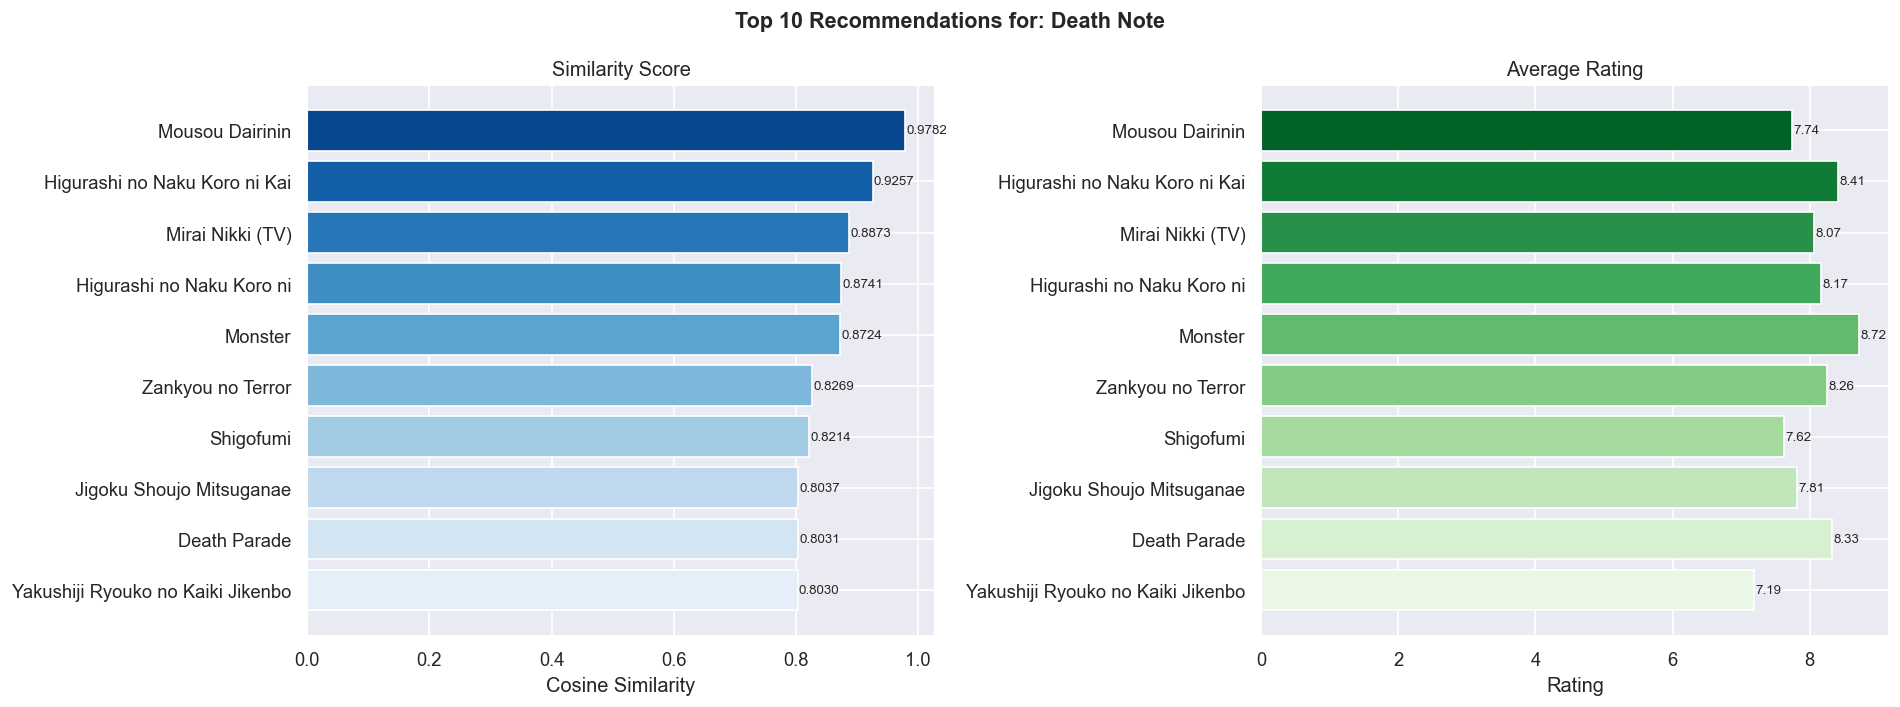

In [65]:
plot_recommendations('Death Note')

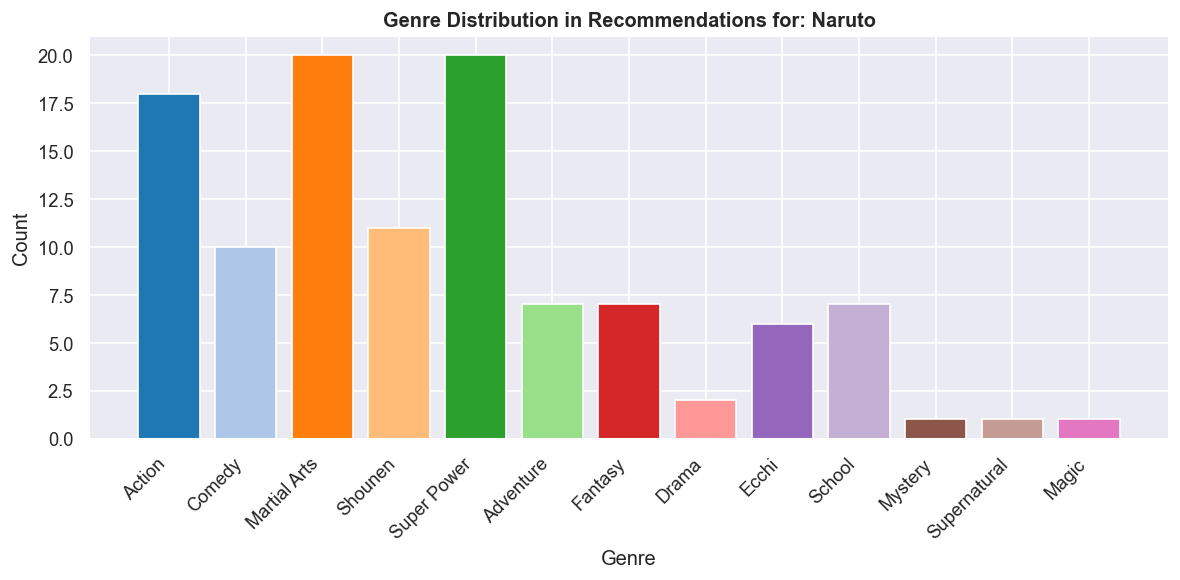

In [66]:
from collections import Counter

def genre_profile(title, n=20):
    recs = recommend_anime(title, n=n)
    if recs is None:
        return

    # Extract all genres from recommendations
    all_genres = recs['genre'].dropna().str.split(',').explode().str.strip()
    genre_counts = Counter(all_genres)

    plt.figure(figsize=(10, 5))
    genres = list(genre_counts.keys())
    counts = list(genre_counts.values())
    colors = sns.color_palette('tab20', len(genres))
    plt.bar(genres, counts, color=colors, edgecolor='white')
    plt.title(f'Genre Distribution in Recommendations for: {title}',
              fontsize=12, fontweight='bold')
    plt.xlabel('Genre'); plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

genre_profile('Naruto')

In [67]:
print("CONTENT BASED RECOMMENDER SYSTEM - SUMMARY")

print(f"""
Approach      : Content-Based Filtering
Features used :
  • Genre     — TF-IDF vectorization (weight × 3)
  • Type      — OneHot encoding (weight × 2)
  • Avg Rating— MinMax normalized (weight × 1)
  • Members   — log1p + MinMax normalized (weight × 1)
  • Episodes  — log1p + MinMax normalized (weight × 1)

Similarity    : Cosine Similarity
Total anime   : {len(anm_cb):,}
Matrix size   : {cosine_sim.shape[0]:,} × {cosine_sim.shape[1]:,}

How it works  :
  1. Each anime is represented as a weighted feature vector
  2. Cosine similarity finds the angle between two vectors
  3. Higher cosine score = more similar anime
  4. Top N anime with highest scores are recommended
""")

CONTENT BASED RECOMMENDER SYSTEM - SUMMARY

Approach      : Content-Based Filtering
Features used :
  • Genre     — TF-IDF vectorization (weight × 3)
  • Type      — OneHot encoding (weight × 2)
  • Avg Rating— MinMax normalized (weight × 1)
  • Members   — log1p + MinMax normalized (weight × 1)
  • Episodes  — log1p + MinMax normalized (weight × 1)

Similarity    : Cosine Similarity
Total anime   : 12,294
Matrix size   : 12,294 × 12,294

How it works  :
  1. Each anime is represented as a weighted feature vector
  2. Cosine similarity finds the angle between two vectors
  3. Higher cosine score = more similar anime
  4. Top N anime with highest scores are recommended

